# 🧠 Week 4 — Day 1: Neural Network Fundamentals

**Topics Covered:**
- PyTorch Tensors (the building blocks)
- Activation Functions (ReLU, Sigmoid, Tanh)
- Multi-Layer Perceptron (MLP) — forward pass
- Loss Functions (MSE, CrossEntropy)
- Backpropagation — how the network *learns*
- Training a 3-layer MLP on tabular data
- Visualizing loss curves & learned weights

---
> 💡 **Goal by end of day:** Build and train a neural network from scratch that classifies tabular data, understand every line of code, and visualize what the network is learning.

---

## 📦 Step 0 — Import Everything We Need

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print(f'✅ PyTorch version: {torch.__version__}')
print(f'✅ Device available: {"GPU (CUDA)" if torch.cuda.is_available() else "CPU"}')
print('✅ All imports successful!')

✅ PyTorch version: 2.12.0+cu130
✅ Device available: CPU
✅ All imports successful!


---
## 🧱 Part 1 — PyTorch Tensors

A **tensor** is just a multi-dimensional array — like a NumPy array, but it can run on a GPU and supports automatic differentiation.

| Shape | Name | Example |
|-------|------|---------|
| `()` | Scalar | A single number: `3.14` |
| `(n,)` | Vector | A list of numbers: `[1, 2, 3]` |
| `(m, n)` | Matrix | A table of numbers |
| `(batch, channels, H, W)` | 4D Tensor | An image batch |

In [2]:
# ── Creating tensors ──────────────────────────────────────────────
scalar  = torch.tensor(3.14)
vector  = torch.tensor([1.0, 2.0, 3.0])
matrix  = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
zeros   = torch.zeros(3, 4)
ones    = torch.ones(2, 3)
random  = torch.randn(3, 3)   # standard normal distribution

print('Scalar:  ', scalar,  '  | shape:', scalar.shape)
print('Vector:  ', vector,  ' | shape:', vector.shape)
print('Matrix:\n', matrix,  '\n  shape:', matrix.shape)
print('\nRandom 3x3 tensor:\n', random)

Scalar:   tensor(3.1400)   | shape: torch.Size([])
Vector:   tensor([1., 2., 3.])  | shape: torch.Size([3])
Matrix:
 tensor([[1., 2.],
        [3., 4.]]) 
  shape: torch.Size([2, 2])

Random 3x3 tensor:
 tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863],
        [ 2.2082, -0.6380,  0.4617]])


In [3]:
# ── Tensor operations (same as NumPy, but GPU-able) ───────────────
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print('a + b       =', a + b)
print('a * b       =', a * b)          # element-wise multiply
print('dot(a, b)   =', torch.dot(a, b))  # dot product = 1*4 + 2*5 + 3*6
print('mean(a)     =', a.mean())
print('a reshaped  =', a.reshape(3, 1).shape)

# Matrix multiply
W = torch.randn(4, 3)   # weight matrix (4 outputs, 3 inputs)
x = torch.randn(3)      # input vector (3 features)
out = W @ x             # matrix-vector multiply  → shape (4,)
print('\nW shape:', W.shape, '  x shape:', x.shape, '  W@x shape:', out.shape)

a + b       = tensor([5., 7., 9.])
a * b       = tensor([ 4., 10., 18.])
dot(a, b)   = tensor(32.)
mean(a)     = tensor(2.)
a reshaped  = torch.Size([3, 1])

W shape: torch.Size([4, 3])   x shape: torch.Size([3])   W@x shape: torch.Size([4])


In [4]:
# ── Autograd: the magic that makes learning possible ──────────────
# requires_grad=True tells PyTorch to track operations for backprop

x = torch.tensor(2.0, requires_grad=True)

# Let's compute y = x^3 + 5x
y = x**3 + 5*x
print(f'y = x³ + 5x  at x=2  →  y = {y.item():.1f}')

# Backpropagate — computes dy/dx automatically
y.backward()
print(f'dy/dx at x=2 = {x.grad.item():.1f}   (expected: 3x² + 5 = 17)')

print('\n🎯 Key insight: PyTorch tracked every operation')
print('   and used the chain rule to compute the gradient!')

y = x³ + 5x  at x=2  →  y = 18.0
dy/dx at x=2 = 17.0   (expected: 3x² + 5 = 17)

🎯 Key insight: PyTorch tracked every operation
   and used the chain rule to compute the gradient!


---
## ⚡ Part 2 — Activation Functions

Without activations, stacking linear layers is **still just linear**. Activation functions add non-linearity so the network can learn complex patterns.

| Function | Formula | When to use |
|----------|---------|-------------|
| **ReLU** | `max(0, x)` | Hidden layers (default choice) |
| **Sigmoid** | `1/(1+e^-x)` | Binary output (0–1 probability) |
| **Tanh** | `(e^x - e^-x)/(e^x + e^-x)` | Hidden layers (zero-centered) |
| **Softmax** | `e^xi / Σe^xj` | Multi-class output (probabilities) |

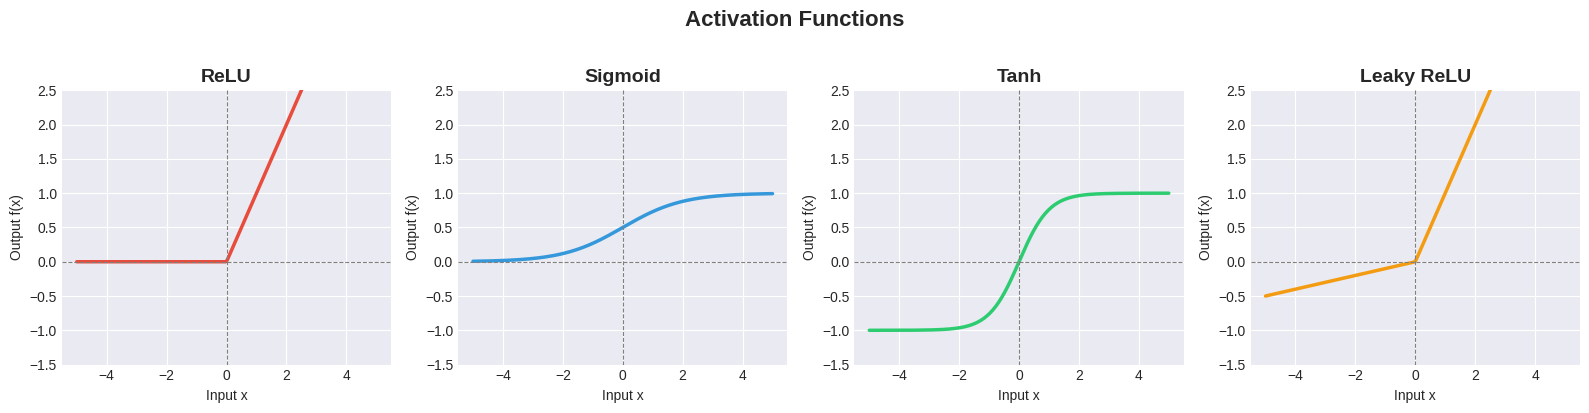

💡 ReLU is king for hidden layers — simple, fast, works great!
💡 Sigmoid squashes to (0,1) — perfect for binary classification outputs.
💡 Tanh squashes to (-1,1) — zero-centered, sometimes better than sigmoid.


In [5]:
x_vals = torch.linspace(-5, 5, 200)

activations = {
    'ReLU':    torch.relu(x_vals),
    'Sigmoid': torch.sigmoid(x_vals),
    'Tanh':    torch.tanh(x_vals),
    'Leaky ReLU': nn.LeakyReLU(0.1)(x_vals),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for ax, (name, vals), color in zip(axes, activations.items(), colors):
    ax.plot(x_vals.numpy(), vals.detach().numpy(), color=color, linewidth=2.5)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.set_xlabel('Input x')
    ax.set_ylabel('Output f(x)')
    ax.set_ylim(-1.5, 2.5)

plt.suptitle('Activation Functions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('💡 ReLU is king for hidden layers — simple, fast, works great!')
print('💡 Sigmoid squashes to (0,1) — perfect for binary classification outputs.')
print('💡 Tanh squashes to (-1,1) — zero-centered, sometimes better than sigmoid.')

---
## 🏗️ Part 3 — Multi-Layer Perceptron (MLP): The Theory

An MLP is layers of **neurons** connected together. Each neuron does:

```
output = activation( W · input + b )
```

A **3-layer MLP** (2 hidden + 1 output) looks like:

```
Input (features)
       ↓
  [Hidden Layer 1]  →  Linear → ReLU
       ↓
  [Hidden Layer 2]  →  Linear → ReLU
       ↓
  [Output Layer]    →  Linear → Softmax (for classification)
       ↓
  Predicted class
```

### Forward Pass vs Backward Pass
- **Forward pass**: input flows *forward* through layers → produces prediction
- **Backward pass**: error flows *backward* through layers → updates weights (learning!)

In [6]:
# ── Manual forward pass (no PyTorch nn) ── understand the math! ───
torch.manual_seed(0)

# Simulated single input: 4 features (like Iris dataset)
x = torch.tensor([5.1, 3.5, 1.4, 0.2])   # shape (4,)

# Layer 1: 4 inputs → 8 neurons
W1 = torch.randn(8, 4) * 0.1
b1 = torch.zeros(8)

# Layer 2: 8 inputs → 4 neurons  
W2 = torch.randn(4, 8) * 0.1
b2 = torch.zeros(4)

# Output: 4 inputs → 3 classes (Iris has 3 classes)
W3 = torch.randn(3, 4) * 0.1
b3 = torch.zeros(3)

# ── FORWARD PASS ─────────────────────────────────────────────────
z1 = W1 @ x + b1                  # linear transform
a1 = torch.relu(z1)               # activation

z2 = W2 @ a1 + b2
a2 = torch.relu(z2)

z3 = W3 @ a2 + b3
probs = torch.softmax(z3, dim=0)  # convert to probabilities

print('Input x:              ', x.numpy())
print('After Layer 1 (ReLU): ', a1.detach().numpy().round(4))
print('After Layer 2 (ReLU): ', a2.detach().numpy().round(4))
print('Raw output (logits):  ', z3.detach().numpy().round(4))
print('Probabilities:        ', probs.detach().numpy().round(4))
print(f'Predicted class:       {probs.argmax().item()}  (class {probs.argmax().item()})')
print(f'Total probability:     {probs.sum().item():.4f}  (always sums to 1!)')

Input x:               [5.1 3.5 1.4 0.2]
After Layer 1 (ReLU):  [0.     0.5885 0.     0.6457 0.     0.     0.1571 1.3794]
After Layer 2 (ReLU):  [0.0888 0.     0.0169 0.2165]
Raw output (logits):   [ 0.0036 -0.0286 -0.0202]
Probabilities:         [0.3396 0.3288 0.3316]
Predicted class:       0  (class 0)
Total probability:     1.0000  (always sums to 1!)


---
## 📉 Part 4 — Loss Functions

The **loss** measures how wrong the network is. Training = minimizing the loss.

| Task | Loss Function | PyTorch |
|------|--------------|------|
| Regression | Mean Squared Error | `nn.MSELoss()` |
| Binary Classification | Binary Cross Entropy | `nn.BCELoss()` |
| Multi-class Classification | Cross Entropy | `nn.CrossEntropyLoss()` |

In [7]:
# ── Loss Function Demo ────────────────────────────────────────────

# MSE Loss (regression)
mse = nn.MSELoss()
pred = torch.tensor([2.5, 0.0, 2.0])
true = torch.tensor([3.0, -0.5, 2.0])
print(f'MSE Loss: {mse(pred, true).item():.4f}  (regression)')

# Cross Entropy Loss (multi-class classification)
ce = nn.CrossEntropyLoss()

# logits: raw scores before softmax, shape (batch, num_classes)
logits_good = torch.tensor([[10.0, 0.1, 0.1]])   # very confident, correct
logits_bad  = torch.tensor([[0.1, 10.0, 0.1]])   # very confident, WRONG
logits_unsure = torch.tensor([[1.0, 1.1, 0.9]])  # unsure
true_class = torch.tensor([0])                   # correct class is 0

print(f'\nCross Entropy Loss:')
print(f'  Confident & correct:  {ce(logits_good,  true_class).item():.4f}  ✅ low loss')
print(f'  Confident & wrong:    {ce(logits_bad,   true_class).item():.4f}  ❌ high loss')
print(f'  Unsure:               {ce(logits_unsure,true_class).item():.4f}  🤔 medium loss')
print('\n💡 The loss punishes confident wrong answers MUCH more than uncertain ones!')

MSE Loss: 0.1667  (regression)

Cross Entropy Loss:
  Confident & correct:  0.0001  ✅ low loss
  Confident & wrong:    9.9001  ❌ high loss
  Unsure:               1.1019  🤔 medium loss

💡 The loss punishes confident wrong answers MUCH more than uncertain ones!


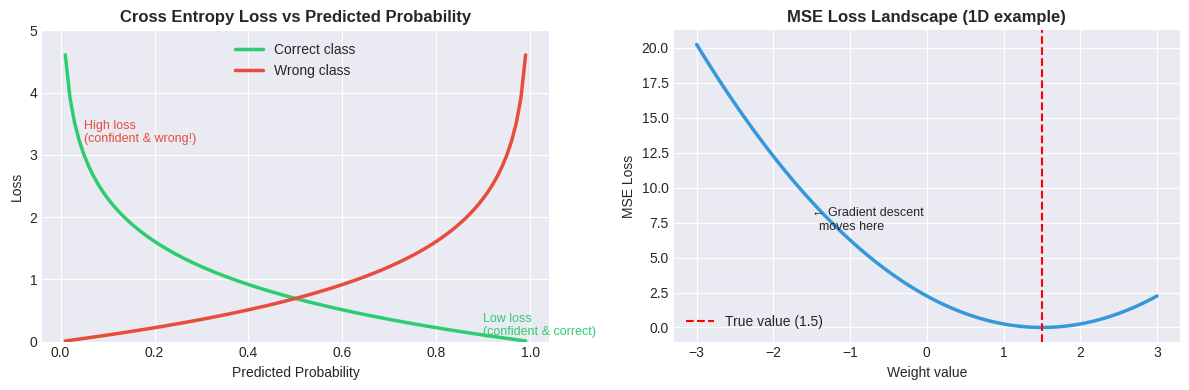

In [8]:
# ── Visualize how Cross Entropy changes with confidence ───────────
probs = np.linspace(0.01, 0.99, 100)
loss_correct = -np.log(probs)      # loss when prediction matches true class
loss_wrong   = -np.log(1 - probs)  # loss when it doesn't

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(probs, loss_correct, color='#2ecc71', linewidth=2.5, label='Correct class')
ax1.plot(probs, loss_wrong,   color='#e74c3c', linewidth=2.5, label='Wrong class')
ax1.set_xlabel('Predicted Probability'); ax1.set_ylabel('Loss')
ax1.set_title('Cross Entropy Loss vs Predicted Probability', fontweight='bold')
ax1.legend(); ax1.set_ylim(0, 5)
ax1.annotate('Low loss\n(confident & correct)', xy=(0.9, 0.1), fontsize=9, color='#2ecc71')
ax1.annotate('High loss\n(confident & wrong!)', xy=(0.05, 3.2), fontsize=9, color='#e74c3c')

# MSE landscape (parabola)
w = np.linspace(-3, 3, 100)
loss_mse = (w - 1.5)**2  # simple 1D MSE landscape, true value = 1.5
ax2.plot(w, loss_mse, color='#3498db', linewidth=2.5)
ax2.axvline(1.5, color='red', linestyle='--', label='True value (1.5)')
ax2.annotate('← Gradient descent\n  moves here', xy=(-1.5, 7), fontsize=9)
ax2.set_xlabel('Weight value'); ax2.set_ylabel('MSE Loss')
ax2.set_title('MSE Loss Landscape (1D example)', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

---
## 🔄 Part 5 — Backpropagation & Gradient Descent

**How does the network learn?**

1. **Forward pass**: compute prediction
2. **Compute loss**: how wrong are we?
3. **Backward pass** (`loss.backward()`): compute gradient of loss w.r.t. every weight
4. **Update weights** (`optimizer.step()`): nudge weights in direction that reduces loss
5. Repeat 1000s of times → loss decreases → network improves!

```
new_weight = old_weight − learning_rate × gradient
```

In [9]:
# ── Tiny 1D example: learn a single weight ────────────────────────
# Goal: find W such that W * 2.0 ≈ 6.0  (so W should be 3.0)

W = torch.tensor(0.1, requires_grad=True)   # start with bad guess
x_in = torch.tensor(2.0)
y_true = torch.tensor(6.0)
lr = 0.1  # learning rate

history = []
print(f'Starting W = {W.item():.4f}  (want W = 3.0)\n')
print(f'{'Step':>4}  {'W':>8}  {'Prediction':>12}  {'Loss':>10}  {'Gradient':>10}')
print('-' * 55)

for step in range(30):
    pred = W * x_in                         # forward pass
    loss = (pred - y_true) ** 2             # MSE loss
    loss.backward()                         # backprop → compute dL/dW
    
    history.append({'step': step, 'W': W.item(), 'loss': loss.item()})
    
    if step < 8 or step == 29:
        print(f'{step:>4}  {W.item():>8.4f}  {pred.item():>12.4f}  {loss.item():>10.4f}  {W.grad.item():>10.4f}')
    elif step == 8:
        print('  ...  (converging ...)')
    
    with torch.no_grad():
        W -= lr * W.grad                    # gradient descent step
    W.grad.zero_()                          # IMPORTANT: reset gradients!

print(f'\n✅ Final W = {W.item():.4f}  (target was 3.0)')

Starting W = 0.1000  (want W = 3.0)

Step         W    Prediction        Loss    Gradient
-------------------------------------------------------
   0    0.1000        0.2000     33.6400    -23.2000
   1    2.4200        4.8400      1.3456     -4.6400
   2    2.8840        5.7680      0.0538     -0.9280
   3    2.9768        5.9536      0.0022     -0.1856
   4    2.9954        5.9907      0.0001     -0.0371
   5    2.9991        5.9981      0.0000     -0.0074
   6    2.9998        5.9996      0.0000     -0.0015
   7    3.0000        5.9999      0.0000     -0.0003
  ...  (converging ...)
  29    3.0000        6.0000      0.0000      0.0000

✅ Final W = 3.0000  (target was 3.0)


---
## 🏛️ Part 6 — Building an MLP with `torch.nn`

Now we stop doing things manually and use PyTorch's clean API.

In [10]:
class MLP(nn.Module):
    """
    3-Layer Multi-Layer Perceptron
    
    Architecture:
        Input  →  Hidden1 (ReLU)  →  Hidden2 (ReLU)  →  Output
    """
    def __init__(self, input_size, hidden1_size, hidden2_size, num_classes):
        super(MLP, self).__init__()
        
        # Define the layers
        self.layer1 = nn.Linear(input_size,    hidden1_size)  # input  → hidden1
        self.layer2 = nn.Linear(hidden1_size,  hidden2_size)  # hidden1 → hidden2
        self.layer3 = nn.Linear(hidden2_size,  num_classes)   # hidden2 → output
        
        self.relu = nn.ReLU()
    
    def forward(self, x):
        """Defines the forward pass"""
        x = self.relu(self.layer1(x))  # Layer 1
        x = self.relu(self.layer2(x))  # Layer 2
        x = self.layer3(x)             # Output (no activation — CrossEntropyLoss handles it)
        return x


# Create the model
model = MLP(input_size=4, hidden1_size=16, hidden2_size=8, num_classes=3)
print('📐 Model Architecture:')
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f'\n📊 Total trainable parameters: {total_params}')

# Quick sanity check: feed dummy input
dummy = torch.randn(5, 4)          # batch of 5 samples, 4 features each
out   = model(dummy)
print(f'\nInput shape:  {dummy.shape}  (batch_size=5, features=4)')
print(f'Output shape: {out.shape}   (batch_size=5, num_classes=3)')

📐 Model Architecture:
MLP(
  (layer1): Linear(in_features=4, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (layer3): Linear(in_features=8, out_features=3, bias=True)
  (relu): ReLU()
)

📊 Total trainable parameters: 243

Input shape:  torch.Size([5, 4])  (batch_size=5, features=4)
Output shape: torch.Size([5, 3])   (batch_size=5, num_classes=3)


---
## 🌸 Part 7 — PROJECT: Classify Iris Flowers with MLP

**The Iris dataset** has 150 samples of flowers with 4 measurements each:
- Sepal length, sepal width, petal length, petal width
- 3 classes: *Setosa*, *Versicolor*, *Virginica*

We will build, train, and evaluate a 3-layer MLP on this dataset — visualizing everything!

### Step 7.1 — Load and Explore the Data

Dataset shape:  X=(150, 4), y=(150,)
Features:       ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes:        ['setosa' 'versicolor' 'virginica']
Class counts:   [50 50 50]  (50 samples per class — balanced!)


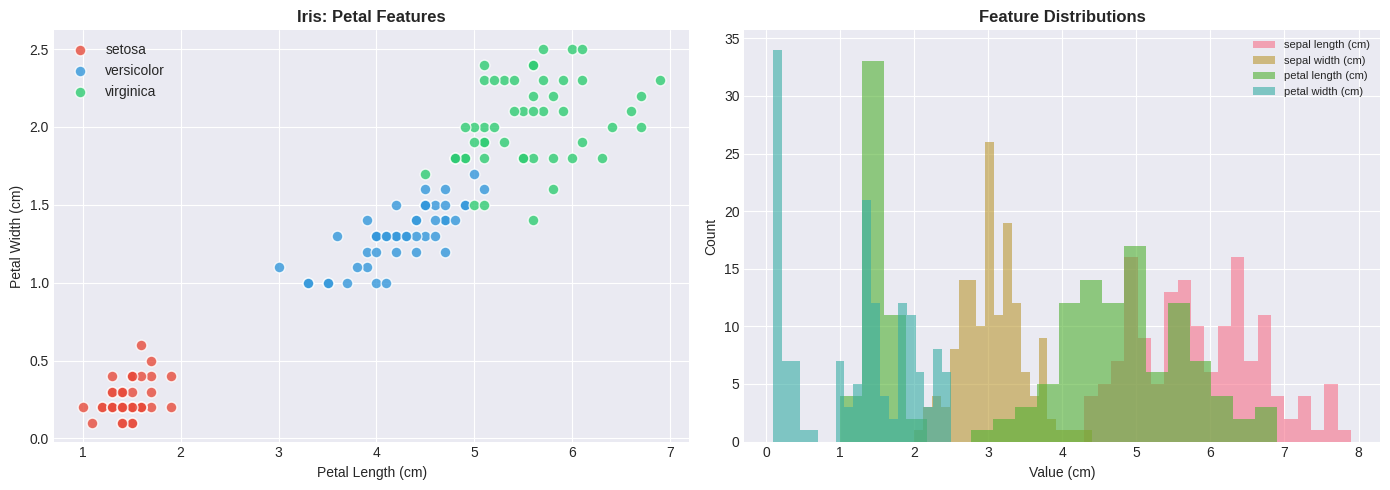

In [11]:
# Load Iris dataset
iris = load_iris()
X, y = iris.data, iris.target
class_names = iris.target_names
feature_names = iris.feature_names

print(f'Dataset shape:  X={X.shape}, y={y.shape}')
print(f'Features:       {feature_names}')
print(f'Classes:        {class_names}')
print(f'Class counts:   {np.bincount(y)}  (50 samples per class — balanced!)')

# Visualize the data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71']

# Plot 1: Petal length vs Petal width
for cls_idx, (cls_name, color) in enumerate(zip(class_names, colors)):
    mask = y == cls_idx
    axes[0].scatter(X[mask, 2], X[mask, 3], c=color, label=cls_name, s=60, alpha=0.8, edgecolors='white')
axes[0].set_xlabel('Petal Length (cm)'); axes[0].set_ylabel('Petal Width (cm)')
axes[0].set_title('Iris: Petal Features', fontweight='bold'); axes[0].legend()

# Plot 2: Feature distributions
for i, feat in enumerate(feature_names):
    axes[1].hist(X[:, i], bins=20, alpha=0.6, label=feat)
axes[1].set_xlabel('Value (cm)'); axes[1].set_ylabel('Count')
axes[1].set_title('Feature Distributions', fontweight='bold'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Step 7.2 — Preprocess: Normalize + Train/Test Split

> **Why normalize?** Raw features have different scales (e.g., petal length 0–7 cm vs. count data). Normalizing makes training faster and more stable.

In [12]:
# ── Train/Test Split ──────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size: {X_train.shape[0]} samples')
print(f'Test size:  {X_test.shape[0]} samples')

# ── Normalize: zero mean, unit variance ──────────────────────────
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit on train only!
X_test  = scaler.transform(X_test)       # apply same transform to test

print(f'\nBefore scaling: mean={iris.data[:,0].mean():.2f}, std={iris.data[:,0].std():.2f}')
print(f'After  scaling: mean={X_train[:,0].mean():.2f}, std={X_train[:,0].std():.2f}')

# ── Convert to PyTorch Tensors ────────────────────────────────────
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.LongTensor(y_train)     # LongTensor for class labels
X_test_t  = torch.FloatTensor(X_test)
y_test_t  = torch.LongTensor(y_test)

# ── DataLoader: handles batching automatically ────────────────────
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=True)

print(f'\nDataLoader: {len(train_loader)} batches of up to 16 samples each')
print('✅ Data ready!')

Train size: 120 samples
Test size:  30 samples

Before scaling: mean=5.84, std=0.83
After  scaling: mean=-0.00, std=1.00

DataLoader: 8 batches of up to 16 samples each
✅ Data ready!


### Step 7.3 — Build & Train the MLP

The **training loop** is the heart of deep learning:

```
for each epoch:
    for each batch:
        1. forward pass → predictions
        2. compute loss
        3. optimizer.zero_grad()  ← clear old gradients
        4. loss.backward()        ← compute new gradients
        5. optimizer.step()       ← update weights
```

In [13]:
# ── Build model, loss, optimizer ─────────────────────────────────
torch.manual_seed(42)
model     = MLP(input_size=4, hidden1_size=16, hidden2_size=8, num_classes=3)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ── Training loop ─────────────────────────────────────────────────
NUM_EPOCHS = 150
train_losses, test_losses, test_accuracies = [], [], []

for epoch in range(NUM_EPOCHS):
    # --- Training phase ---
    model.train()
    epoch_loss = 0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()              # 1. clear gradients
        predictions = model(X_batch)       # 2. forward pass
        loss = criterion(predictions, y_batch)  # 3. compute loss
        loss.backward()                    # 4. backpropagation
        optimizer.step()                   # 5. update weights
        epoch_loss += loss.item()
    
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # --- Evaluation phase ---
    model.eval()
    with torch.no_grad():                  # no gradients needed for eval
        test_out  = model(X_test_t)
        test_loss = criterion(test_out, y_test_t).item()
        preds     = test_out.argmax(dim=1)
        accuracy  = (preds == y_test_t).float().mean().item() * 100
    
    test_losses.append(test_loss)
    test_accuracies.append(accuracy)
    
    if (epoch + 1) % 25 == 0:
        print(f'Epoch [{epoch+1:3d}/{NUM_EPOCHS}]  '
              f'Train Loss: {avg_train_loss:.4f}  '
              f'Test Loss: {test_loss:.4f}  '
              f'Test Accuracy: {accuracy:.1f}%')

print(f'\n🎉 Final Test Accuracy: {test_accuracies[-1]:.1f}%')

Epoch [ 25/150]  Train Loss: 0.0435  Test Loss: 0.0909  Test Accuracy: 93.3%
Epoch [ 50/150]  Train Loss: 0.0304  Test Loss: 0.0859  Test Accuracy: 96.7%


Epoch [ 75/150]  Train Loss: 0.0240  Test Loss: 0.0806  Test Accuracy: 96.7%
Epoch [100/150]  Train Loss: 0.0171  Test Loss: 0.1037  Test Accuracy: 96.7%


Epoch [125/150]  Train Loss: 0.0119  Test Loss: 0.1140  Test Accuracy: 96.7%
Epoch [150/150]  Train Loss: 0.0059  Test Loss: 0.1260  Test Accuracy: 93.3%

🎉 Final Test Accuracy: 93.3%


### Step 7.4 — Visualize Training (Loss Curves)

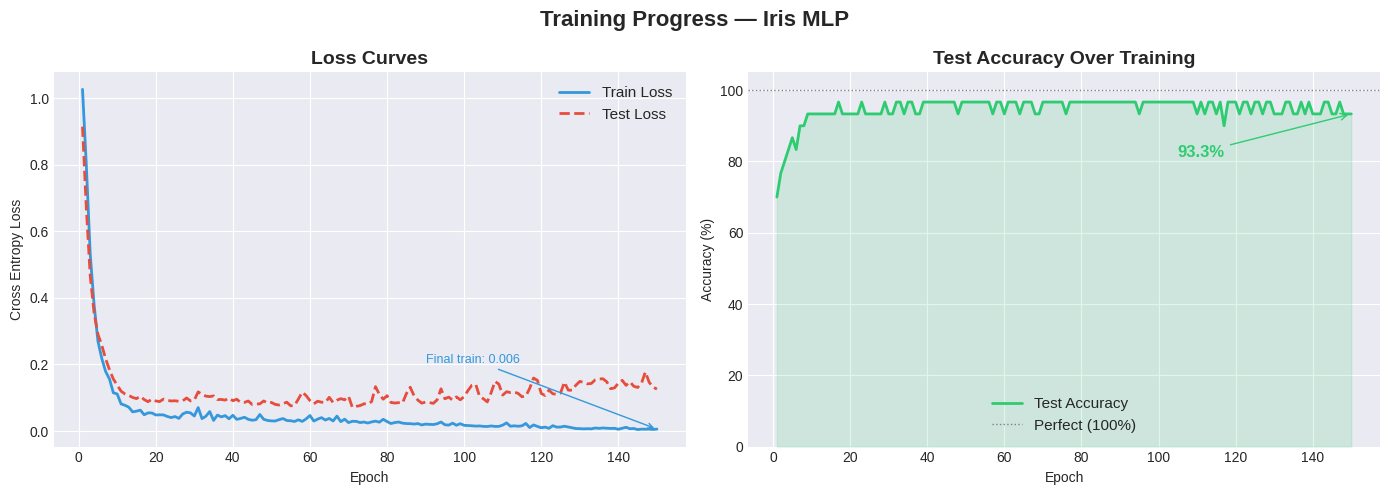

💡 Healthy training looks like:
   ✅ Both train and test loss steadily decreasing
   ✅ Test accuracy increasing
   ⚠️  If test loss increases while train loss drops → overfitting!


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, NUM_EPOCHS + 1)

# Loss curves
ax1.plot(epochs, train_losses, color='#3498db', linewidth=2, label='Train Loss')
ax1.plot(epochs, test_losses,  color='#e74c3c', linewidth=2, label='Test Loss',  linestyle='--')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross Entropy Loss')
ax1.set_title('Loss Curves', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.annotate(f'Final train: {train_losses[-1]:.3f}', 
             xy=(NUM_EPOCHS, train_losses[-1]), xytext=(NUM_EPOCHS*0.6, train_losses[-1]+0.2),
             arrowprops=dict(arrowstyle='->', color='#3498db'), fontsize=9, color='#3498db')

# Accuracy curve
ax2.plot(epochs, test_accuracies, color='#2ecc71', linewidth=2, label='Test Accuracy')
ax2.axhline(y=100, color='gray', linewidth=1, linestyle=':', label='Perfect (100%)')
ax2.fill_between(epochs, test_accuracies, alpha=0.15, color='#2ecc71')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Test Accuracy Over Training', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 105); ax2.legend(fontsize=11)
ax2.annotate(f'{test_accuracies[-1]:.1f}%', 
             xy=(NUM_EPOCHS, test_accuracies[-1]), fontsize=12, fontweight='bold', color='#2ecc71',
             xytext=(NUM_EPOCHS*0.7, test_accuracies[-1]-12),
             arrowprops=dict(arrowstyle='->', color='#2ecc71'))

plt.suptitle('Training Progress — Iris MLP', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Healthy training looks like:')
print('   ✅ Both train and test loss steadily decreasing')
print('   ✅ Test accuracy increasing')
print('   ⚠️  If test loss increases while train loss drops → overfitting!')

### Step 7.5 — Evaluate: Confusion Matrix & Classification Report

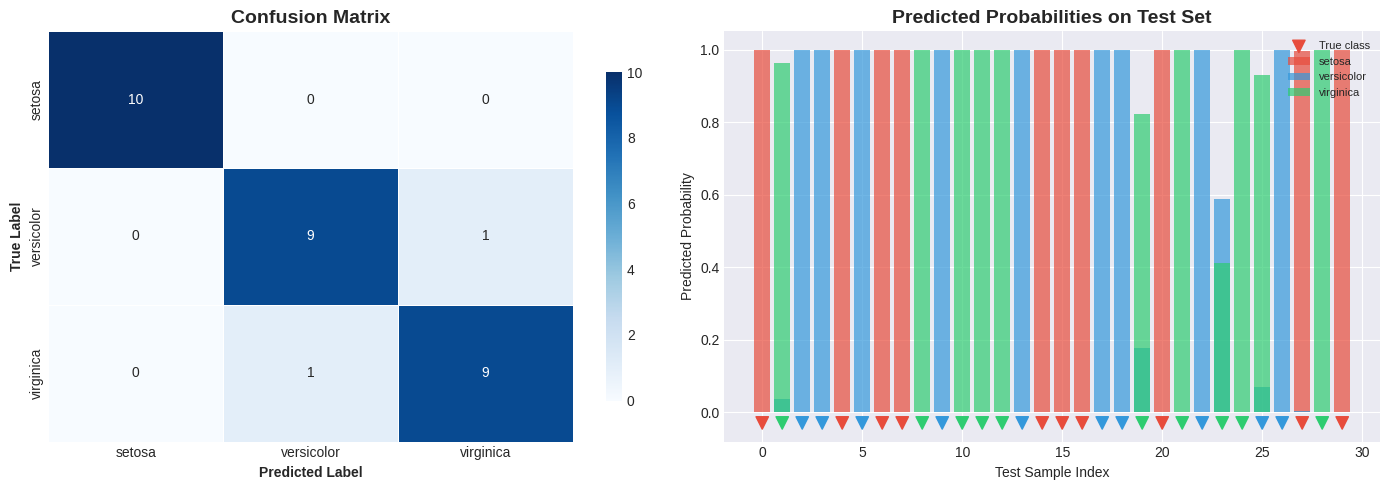


📊 Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [15]:
model.eval()
with torch.no_grad():
    logits     = model(X_test_t)
    probs_pred = torch.softmax(logits, dim=1)
    y_pred     = logits.argmax(dim=1).numpy()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax1.set_xlabel('Predicted Label', fontweight='bold')
ax1.set_ylabel('True Label', fontweight='bold')
ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# Predicted probability bars for test set
colors_bar = ['#e74c3c', '#3498db', '#2ecc71']
for i, cls in enumerate(class_names):
    ax2.bar(range(len(y_test)), probs_pred[:, i].numpy(), 
            label=cls, alpha=0.7, color=colors_bar[i])

# Overlay true labels
ax2.scatter(range(len(y_test)), [-0.03]*len(y_test),
            c=[colors_bar[i] for i in y_test], s=80, zorder=5, 
            marker='v', label='True class')
ax2.set_xlabel('Test Sample Index'); ax2.set_ylabel('Predicted Probability')
ax2.set_title('Predicted Probabilities on Test Set', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

print('\n📊 Classification Report:')
print(classification_report(y_test, y_pred, target_names=class_names))

### Step 7.6 — Visualize Learned Weights

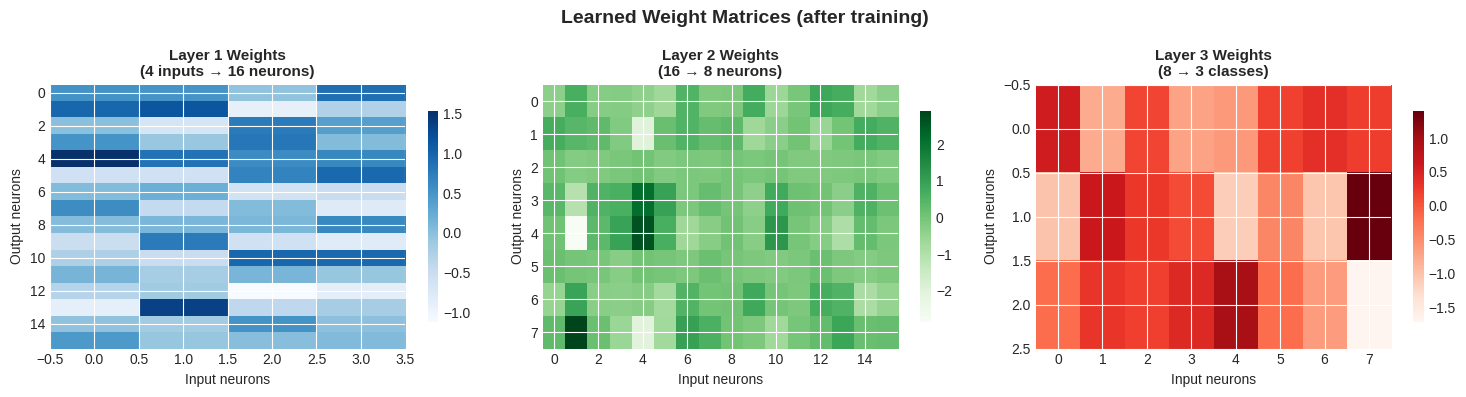

💡 The weight matrices show what the network learned:
   Bright cells = strong positive connection
   Dark cells   = strong negative connection
   Near-zero    = that connection matters less


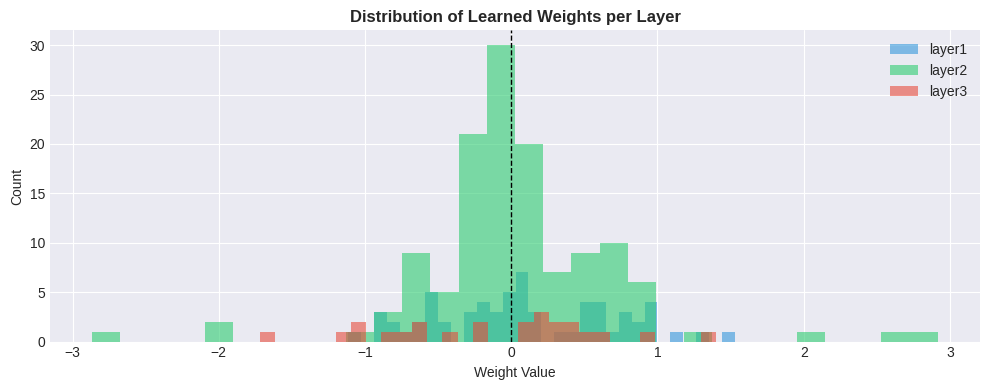

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

layers = [
    (model.layer1.weight.data, 'Layer 1 Weights\n(4 inputs → 16 neurons)', 'Blues'),
    (model.layer2.weight.data, 'Layer 2 Weights\n(16 → 8 neurons)', 'Greens'),
    (model.layer3.weight.data, 'Layer 3 Weights\n(8 → 3 classes)', 'Reds'),
]

for ax, (weights, title, cmap) in zip(axes, layers):
    im = ax.imshow(weights.numpy(), cmap=cmap, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Input neurons'); ax.set_ylabel('Output neurons')

plt.suptitle('Learned Weight Matrices (after training)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 The weight matrices show what the network learned:')
print('   Bright cells = strong positive connection')
print('   Dark cells   = strong negative connection')
print('   Near-zero    = that connection matters less')

# Weight magnitude distribution
fig, ax = plt.subplots(figsize=(10, 4))
all_weights = []
labels = []
for name, param in model.named_parameters():
    if 'weight' in name:
        all_weights.append(param.data.flatten().numpy())
        labels.append(name.replace('.weight', ''))

colors_w = ['#3498db', '#2ecc71', '#e74c3c']
for w, lbl, c in zip(all_weights, labels, colors_w):
    ax.hist(w, bins=30, alpha=0.6, label=lbl, color=c)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Weight Value'); ax.set_ylabel('Count')
ax.set_title('Distribution of Learned Weights per Layer', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 🚀 Part 8 — Learning Rate Experiment

The **learning rate (lr)** is the most important hyperparameter. Too high → diverges. Too low → learns slowly.

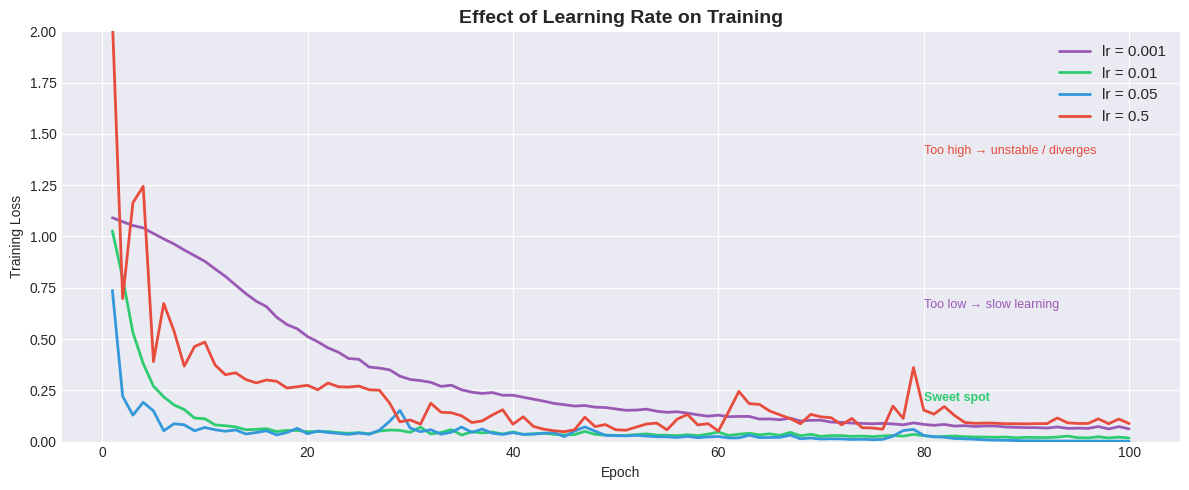

💡 lr=0.01 (green) hits the sweet spot: fast AND stable!


In [17]:
def train_with_lr(lr, epochs=100):
    """Train a fresh model with a given learning rate and return loss history."""
    torch.manual_seed(42)
    m = MLP(4, 16, 8, 3)
    opt = optim.Adam(m.parameters(), lr=lr)
    losses = []
    for _ in range(epochs):
        m.train()
        ep_loss = 0
        for Xb, yb in train_loader:
            opt.zero_grad()
            loss = criterion(m(Xb), yb)
            loss.backward()
            opt.step()
            ep_loss += loss.item()
        losses.append(ep_loss / len(train_loader))
    return losses

learning_rates = [0.001, 0.01, 0.05, 0.5]
lr_colors      = ['#9b59b6', '#2ecc71', '#3498db', '#e74c3c']

fig, ax = plt.subplots(figsize=(12, 5))
for lr, color in zip(learning_rates, lr_colors):
    losses = train_with_lr(lr)
    ax.plot(range(1, 101), losses, label=f'lr = {lr}', color=color, linewidth=2)

ax.set_xlabel('Epoch'); ax.set_ylabel('Training Loss')
ax.set_title('Effect of Learning Rate on Training', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 2.0)

# Annotations
ax.annotate('Too high → unstable / diverges', xy=(80, 1.4), fontsize=9, color='#e74c3c')
ax.annotate('Sweet spot', xy=(80, 0.2), fontsize=9, color='#2ecc71', fontweight='bold')
ax.annotate('Too low → slow learning', xy=(80, 0.65), fontsize=9, color='#9b59b6')

plt.tight_layout()
plt.show()

print('💡 lr=0.01 (green) hits the sweet spot: fast AND stable!')

---
## 🔮 Part 9 — Making Predictions on New Data

In [18]:
def predict_flower(sepal_length, sepal_width, petal_length, petal_width):
    """Predict the Iris species from raw measurements."""
    # Preprocess: normalize with the same scaler used during training
    raw = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
    normalized = scaler.transform(raw)
    tensor_in  = torch.FloatTensor(normalized)
    
    # Predict
    model.eval()
    with torch.no_grad():
        logits = model(tensor_in)
        probs  = torch.softmax(logits, dim=1).squeeze()
    
    predicted_class = probs.argmax().item()
    print(f'\nInput: sepal={sepal_length}x{sepal_width}, petal={petal_length}x{petal_width}')
    for i, (name, p) in enumerate(zip(class_names, probs)):
        bar = '█' * int(p.item() * 30)
        marker = ' ← predicted!' if i == predicted_class else ''
        print(f'  {name:15} {p.item():.3f}  |{bar}{marker}')
    return class_names[predicted_class]

# Test with known examples
print('=== Prediction Examples ===')
predict_flower(5.1, 3.5, 1.4, 0.2)   # typical Setosa
predict_flower(6.0, 2.9, 4.5, 1.5)   # typical Versicolor  
predict_flower(6.5, 3.0, 5.5, 1.8)   # typical Virginica

=== Prediction Examples ===

Input: sepal=5.1x3.5, petal=1.4x0.2
  setosa          1.000  |█████████████████████████████ ← predicted!
  versicolor      0.000  |
  virginica       0.000  |

Input: sepal=6.0x2.9, petal=4.5x1.5
  setosa          0.000  |
  versicolor      1.000  |█████████████████████████████ ← predicted!
  virginica       0.000  |

Input: sepal=6.5x3.0, petal=5.5x1.8
  setosa          0.000  |
  versicolor      0.000  |
  virginica       1.000  |█████████████████████████████ ← predicted!


np.str_('virginica')

---
## 📋 Day 1 Summary

| Concept | What you learned |
|---------|------------------|
| **PyTorch Tensors** | Multi-dim arrays with autograd support |
| **Activation Functions** | ReLU (hidden layers), Softmax (output) |
| **MLP Architecture** | Input → Hidden1 → Hidden2 → Output |
| **Loss Functions** | CrossEntropy for classification |
| **Training Loop** | zero_grad → forward → loss → backward → step |
| **Visualization** | Loss curves, weight matrices, confusion matrix |
| **Hyperparameters** | Learning rate is critical! |

---

## 🏋️ Exercises for Practice

1. **Change the architecture**: Try 3 hidden layers, or different sizes (32-16-8). Does accuracy improve?
2. **Change the optimizer**: Replace `Adam` with `optim.SGD(lr=0.1)`. What happens?
3. **Overfit on purpose**: Remove test split and train for 500 epochs. Watch train loss go to ~0!
4. **New dataset**: Replace Iris with `make_classification(n_features=10, n_classes=4)` and build an MLP for it.
5. **Add weight decay**: Use `optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)` — what does it do to the weight distributions?
